In [1]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, accuracy_score, f1_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt  

In [2]:
data = pd.read_csv("loan_approval_data.csv")


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# handle to Missing values

In [4]:
catagorical_col = data.select_dtypes(include = ["object"]).columns
numerical_col = data.select_dtypes(include = ["number"]).columns

In [5]:
catagorical_col.size + numerical_col.size

20

In [6]:
catagorical_col

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [7]:
numerical_col 

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [8]:
from sklearn.impute import SimpleImputer # ye imputer ha iska kaam numerical orr catagorical values ko ("mean"
# "median", "most frequent") values se fill karna hota hai. 
num_imp = SimpleImputer(strategy= "mean") # sary data ke numerical column ki null values ko mean se fill kia hai 
data[numerical_col] = num_imp.fit_transform(data[numerical_col])


In [9]:
cat_imp = SimpleImputer(strategy= "most_frequent") # orr yahan object values ko fill kia hai yahan "most_frequent"
# ka matlab hai jo cheez zada repeat ho rahi ho
data[catagorical_col] = cat_imp.fit_transform(data[catagorical_col])


# EDA (Exploratory Data Analysis)

Text(0.5, 1.0, 'Loan approval chart')

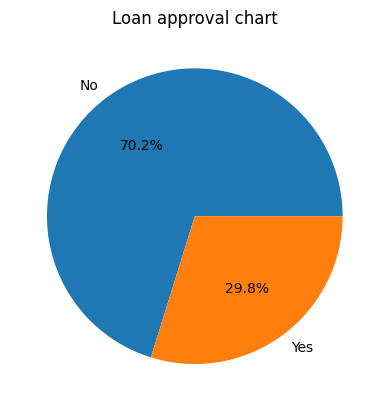

In [10]:
# sab se pehlyy hum ye check krenge classes kitni balanced han  yani output "yes" or "no"
# ki kia percent hai 
class_per = data["Loan_Approved"].value_counts() # agr ek column men 2,3,4 ya 5 catagory tu har catagory ka count 
# alag alag ajata hai  
plt.pie(class_per, labels = class_per.index, autopct = "%1.1f%%")
plt.title("Loan approval chart")

[Text(0, 0, '621'), Text(0, 0, '379')]

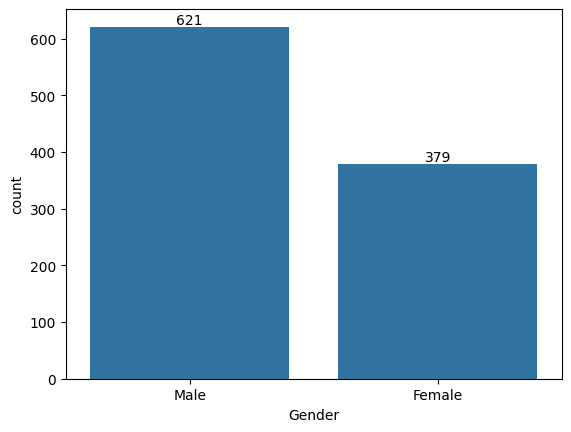

In [11]:
gender_cnt = data["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '643'), Text(0, 0, '357')]

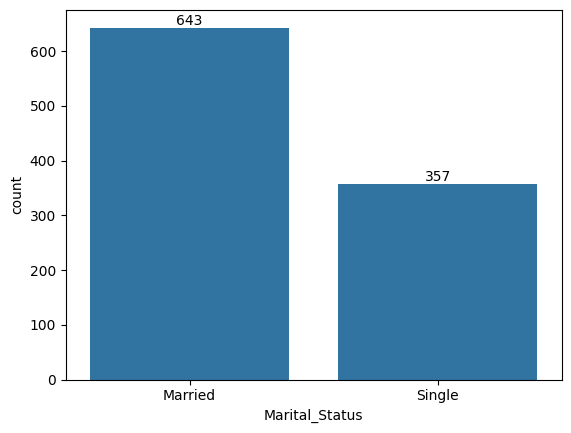

In [12]:
marital_cnt = data["Marital_Status"].value_counts()
ax = sns.barplot(marital_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

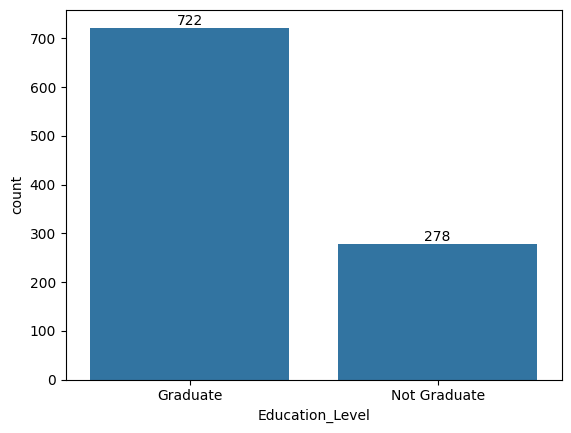

In [13]:
education_cnt = data["Education_Level"].value_counts()
ax = sns.barplot(education_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

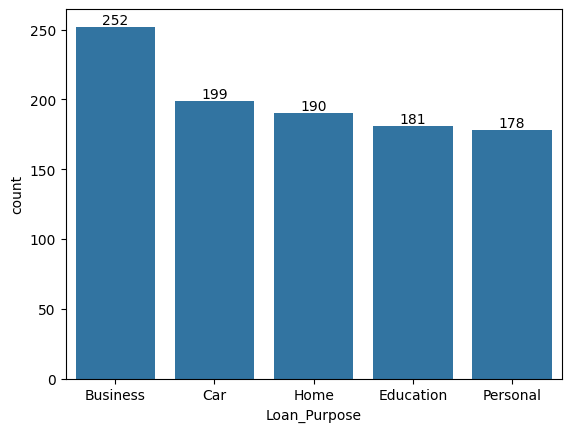

In [14]:
loan_pur_cnt = data["Loan_Purpose"].value_counts()
ax = sns.barplot(loan_pur_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

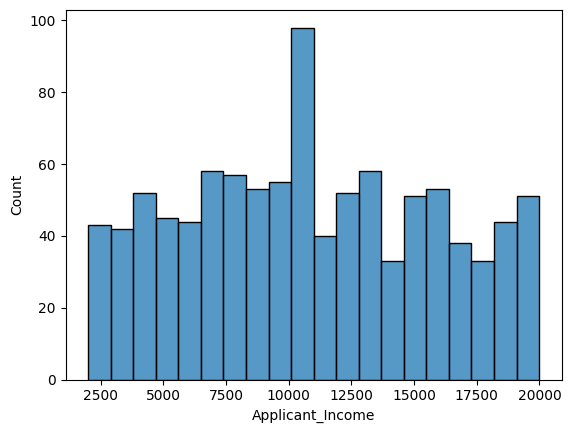

In [15]:
sns.histplot(
    data = data,
    x = "Applicant_Income", 
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

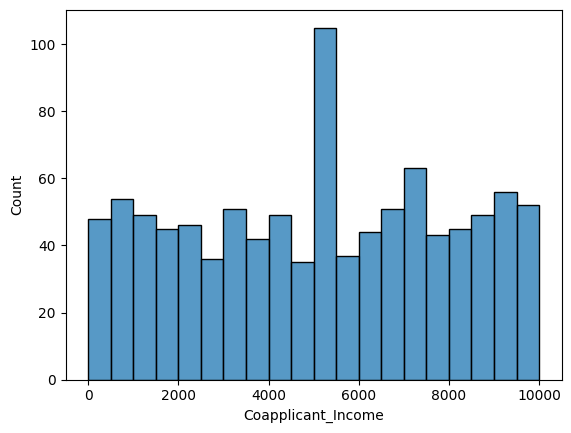

In [16]:
sns.histplot(
    data = data,
    x = "Coapplicant_Income", 
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

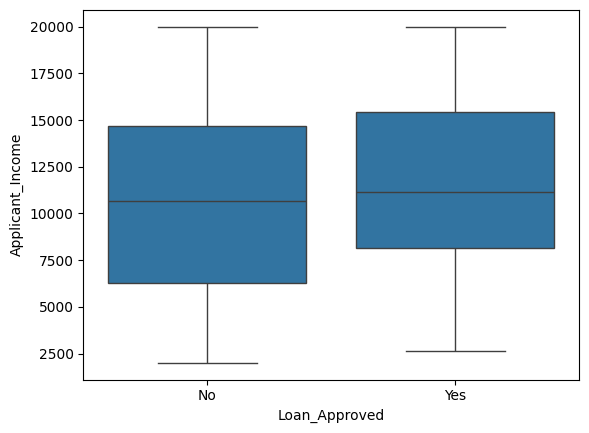

In [17]:
sns.boxplot(
    data = data, 
    
    y = "Applicant_Income",
    x = "Loan_Approved"
)

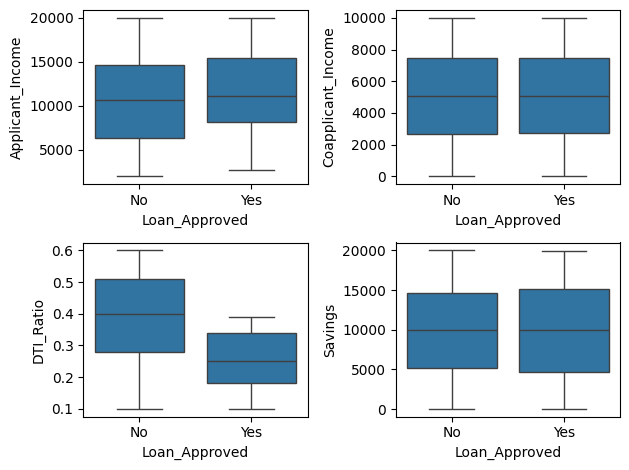

In [18]:
# har value ko analyze karne ke liye box plot bnaienge orr different value ko output ke stah compare krenge
fig, axes = plt.subplots(2,2)
sns.boxplot(ax = axes[0,0], data = data, x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax = axes[0,1], data = data, x = "Loan_Approved", y = "Coapplicant_Income")
sns.boxplot(ax = axes[1,0], data = data, x = "Loan_Approved", y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1], data = data, x = "Loan_Approved", y = "Savings")
plt.tight_layout()

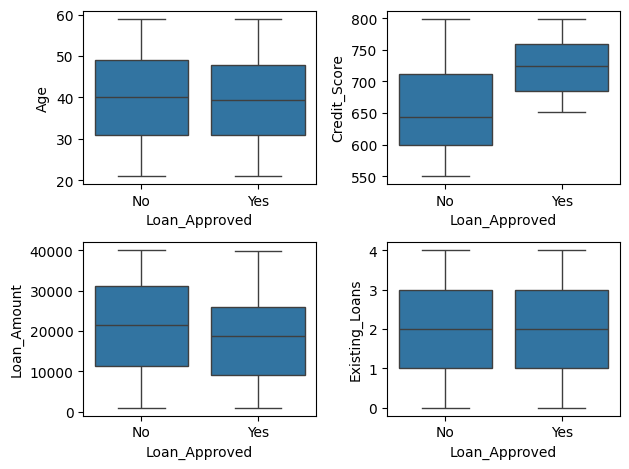

In [19]:
fig, axe = plt.subplots(2,2)
sns.boxplot(ax= axe[0,0], data = data, x = "Loan_Approved", y = "Age")
sns.boxplot(ax= axe[0,1], data = data, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax= axe[1,0], data = data, x = "Loan_Approved", y = "Loan_Amount")
sns.boxplot(ax= axe[1,1], data = data, x = "Loan_Approved", y = "Existing_Loans")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

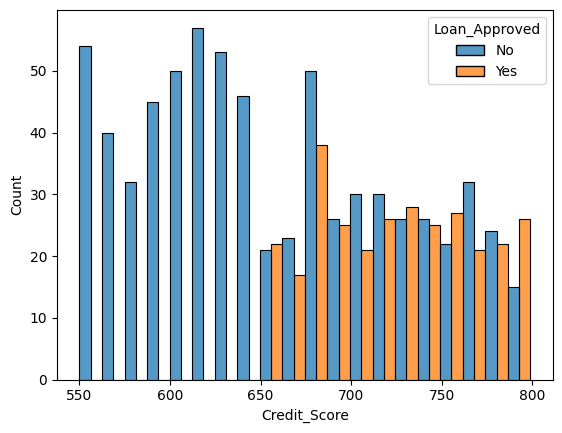

In [20]:
sns.histplot(
    data = data, 
    x = "Credit_Score",
    bins = 20,
    hue = "Loan_Approved",
    multiple = "dodge"
)

In [21]:
data.drop(columns = "Applicant_ID", axis = 1,inplace = True)

In [22]:
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Encoding feature  

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

# OneHotEncoder

In [24]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder # nominal and ordinal data 
# 2 encoder import karne ka maqsad hai "labelEncoder" ko hum use krengge levels ke liye yani education men hun 
# level ko rkhna chahthe han jese matric = 0, inter = 1, graduate = 2 "labelEncoder" ek hee column men 
# multiple catagory level wise jis men graduate ko zada value mili hai or matric ko kam hai 
# OneHotEncoder usa hota hai jahan sare classes ko level rakhna ho jese Male = 1, Female = 1, Child = 1 yaha 
# ko competition ni hai sb equality men han 
col = ["Employment_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category", "Marital_Status"]
one = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore") # yahan drop first ka matab
# ka mtalab first column drop kardo wahi get_dummies ki tarhan "sparse_output" = false  ka matlab hai numpy 2D 
# matrix output aaie agr "sparse_output" = True ho output 2D numpy array ni aaiega "sparse matrix" aaie jisse 
#  pandas dataframe men convert karna mushkil ho ja ta hai handle_unknown = "ignore" ka matlab hai jis data per 
# model train hua hai agr koie new data model ko milta hai tu us condition men wo error ni dega orr agr issy 
# ignore na kren tu error aaiega.
encode = one.fit_transform(data[col])
encode_data = pd.DataFrame(encode, columns = one.get_feature_names_out(col), index = data.index) 
# one = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore") ye line kch is tareeqea 
# ka output degi 
# [[1 0 0]
#  [0 1 0]
#  [0 0 1]]
# jis men columns name ni honge 
# one.get_feature_names_out(col) ye command cloumns name return karti hai or sare column name deta hai jo fit 
# fit karte time hum isyy dete han 
# index = data.index Ye ensure karta hai ke encoded data ki har row original data ki same row ke sath match kare.
# masla tab ata hai jab data shuffled ho ya rows delete hun 
# encode_data koo data frame men convert kia hai 


In [25]:
one.get_feature_names_out(col)

array(['Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Loan_Purpose_Car',
       'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male',
       'Employer_Category_Government', 'Employer_Category_MNC',
       'Employer_Category_Private', 'Employer_Category_Unemployed',
       'Marital_Status_Single'], dtype=object)

In [26]:
encode_data 

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Marital_Status_Single
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
997,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
998,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0


In [27]:
data = pd.concat([data.drop(columns= col), encode_data], axis = 1)# yahan new columns ko 
# data ke sath add kiya hai "data.drop(columns= col)" is command se old data ko encode krne ke bad delete kardiya.

# label encoding

In [28]:
# label encoding men columns ki value level wise hoti hai or target column bhi labelending men lia jata hai 
label = LabelEncoder()
data["Education_Level"] = label.fit_transform(data["Education_Level"])
data["Loan_Approved"] = label.fit_transform(data["Loan_Approved"])

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Heatmap Correlation 

In [30]:
num_col = data.select_dtypes(include= ["number"])
matrix = num_col.corr()["Loan_Approved"].sort_values(ascending= False)
matrix

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

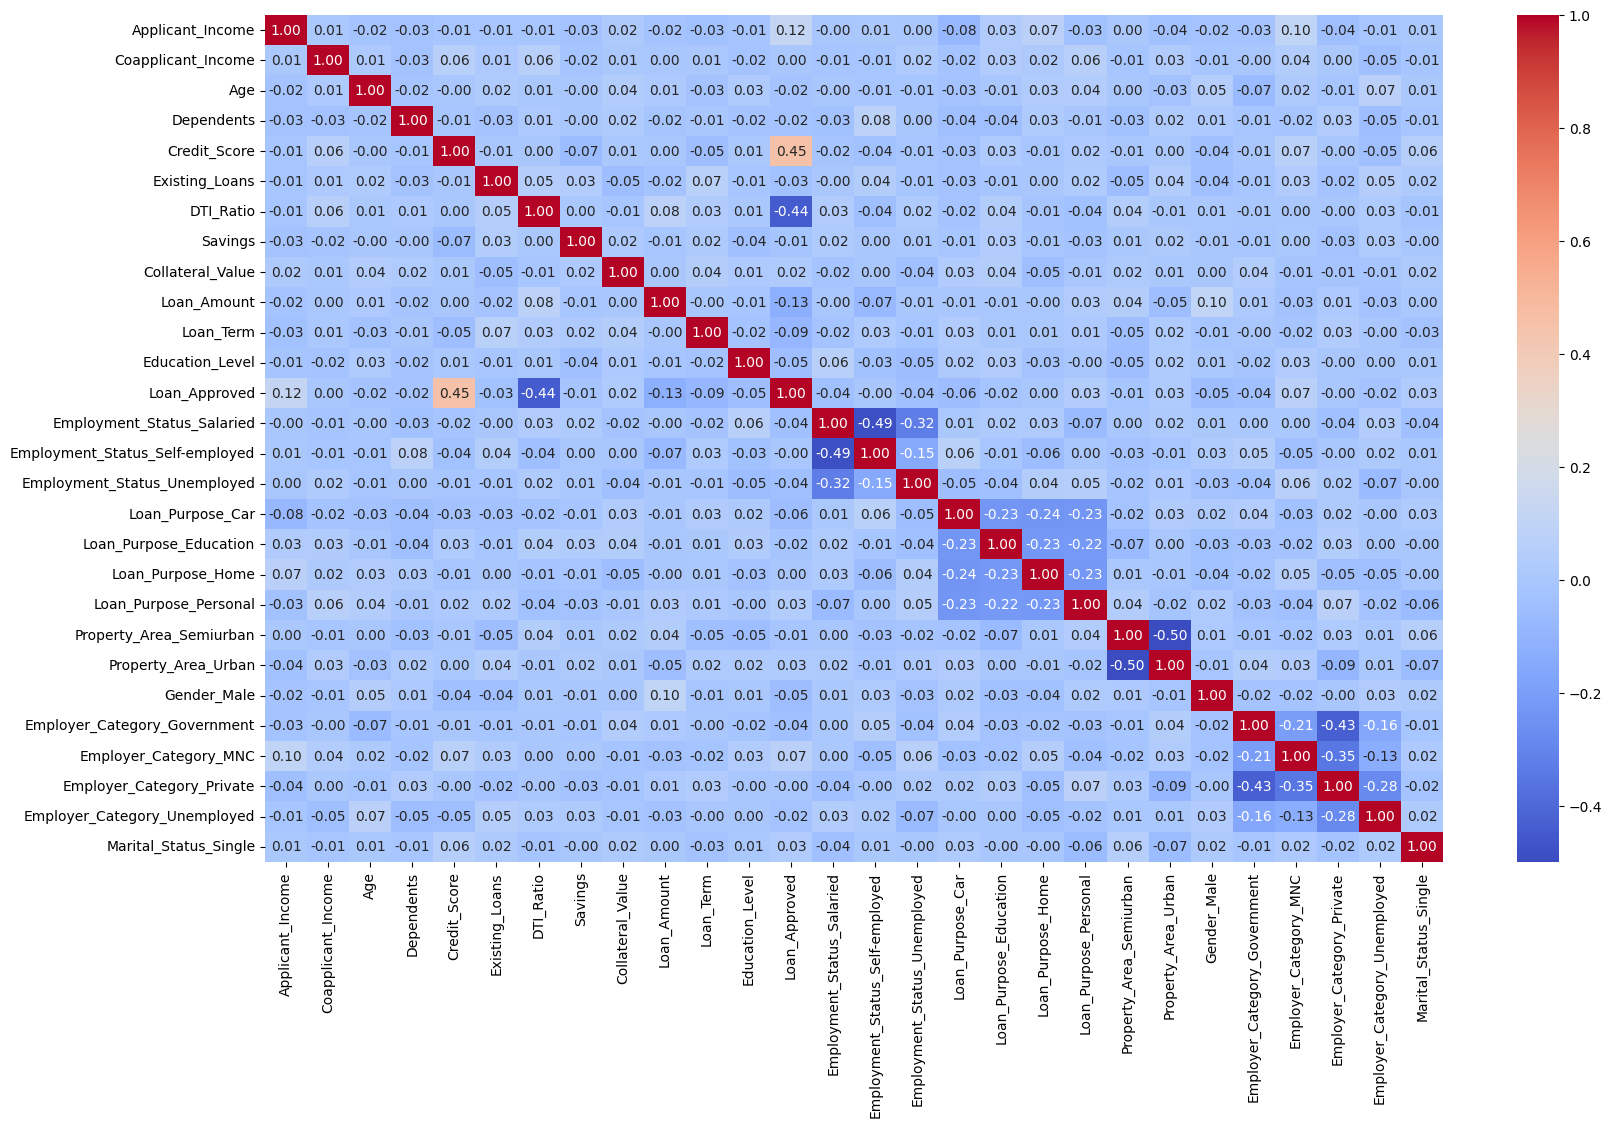

In [31]:
num_col = data.select_dtypes(include= ["number"])
matrix = num_col.corr()
plt.figure(figsize=(19,11))
sns.heatmap(
    matrix, 
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

# Train test split + feature engineering 

In [32]:
X = data.drop(columns = "Loan_Approved", axis= 1)
Y = data["Loan_Approved"]

In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and evaluate the model

In [34]:
# Logistics Regression 
log_model = LogisticRegression()
log_model.fit(X_train_scaled, Y_train)
y_pre = log_model.predict(X_test_scaled)
print("LogisticRegression")
print("accuracy :", accuracy_score(Y_test , y_pre))
print("precision :", precision_score(Y_test , y_pre))
print("recall :", recall_score(Y_test , y_pre))
print("f1_score :", f1_score(Y_test , y_pre))
print("cm :", confusion_matrix(Y_test , y_pre))

LogisticRegression
accuracy : 0.865
precision : 0.7833333333333333
recall : 0.7704918032786885
f1_score : 0.7768595041322314
cm : [[126  13]
 [ 14  47]]


In [35]:
# KNN_neighbours 
from sklearn.neighbors import KNeighborsClassifier
Knn_model = KNeighborsClassifier(n_neighbors = 13)
Knn_model.fit(X_train_scaled, Y_train)
y_pre = Knn_model.predict(X_test_scaled)
print("KNeighborsClassifier")
print("accuracy :", accuracy_score(Y_test , y_pre))
print("precision :", precision_score(Y_test , y_pre))
print("recall :", recall_score(Y_test , y_pre))
print("f1_score :", f1_score(Y_test , y_pre))
print("cm :", confusion_matrix(Y_test , y_pre))

KNeighborsClassifier
accuracy : 0.79
precision : 0.7317073170731707
recall : 0.4918032786885246
f1_score : 0.5882352941176471
cm : [[128  11]
 [ 31  30]]


In [36]:
# Naive_base
from sklearn.naive_bayes import GaussianNB
nb_model =  GaussianNB()
nb_model.fit(X_train_scaled, Y_train)
y_pre = nb_model.predict(X_test_scaled)
print("GaussianNB")
print("accuracy :", accuracy_score(Y_test , y_pre))
print("precision :", precision_score(Y_test , y_pre))
print("recall :", recall_score(Y_test , y_pre))
print("f1_score :", f1_score(Y_test , y_pre))
print("cm :", confusion_matrix(Y_test , y_pre))

GaussianNB
accuracy : 0.865
precision : 0.8035714285714286
recall : 0.7377049180327869
f1_score : 0.7692307692307693
cm : [[128  11]
 [ 16  45]]


# feature engineering 

In [37]:
data["Credit_Score_sq"] = data["Credit_Score"] ** 2
data["DTI_Ratio_sq"] = data["DTI_Ratio"] ** 2
X = data.drop(columns= ["Credit_Score", "DTI_Ratio", "Loan_Approved"])
Y = data["Loan_Approved"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# Logistics Regression 
log_model = LogisticRegression()
log_model.fit(X_train_scaled, Y_train)
y_pre = log_model.predict(X_test_scaled)
print("LogisticRegression")
print("accuracy :", accuracy_score(Y_test , y_pre))
print("precision :", precision_score(Y_test , y_pre))
print("recall :", recall_score(Y_test , y_pre))
print("f1_score :", f1_score(Y_test , y_pre))
print("cm :", confusion_matrix(Y_test , y_pre))

LogisticRegression
accuracy : 0.875
precision : 0.7903225806451613
recall : 0.8032786885245902
f1_score : 0.7967479674796748
cm : [[126  13]
 [ 12  49]]


In [39]:
# KNN_neighbours 
from sklearn.neighbors import KNeighborsClassifier
Knn_model = KNeighborsClassifier(n_neighbors = 11)
Knn_model.fit(X_train_scaled, Y_train)
y_pre = Knn_model.predict(X_test_scaled)
print("KNeighborsClassifier")
print("accuracy :", accuracy_score(Y_test , y_pre))
print("precision :", precision_score(Y_test , y_pre))
print("recall :", recall_score(Y_test , y_pre))
print("f1_score :", f1_score(Y_test , y_pre))
print("cm :", confusion_matrix(Y_test , y_pre))

KNeighborsClassifier
accuracy : 0.8
precision : 0.7560975609756098
recall : 0.5081967213114754
f1_score : 0.6078431372549019
cm : [[129  10]
 [ 30  31]]


In [40]:
# Naive_base
from sklearn.naive_bayes import GaussianNB
nb_model =  GaussianNB()
nb_model.fit(X_train_scaled, Y_train)
y_pre = nb_model.predict(X_test_scaled)
print("GaussianNB")
print("accuracy :", accuracy_score(Y_test , y_pre))
print("precision :", precision_score(Y_test , y_pre))
print("recall :", recall_score(Y_test , y_pre))
print("f1_score :", f1_score(Y_test , y_pre))
print("cm :", confusion_matrix(Y_test , y_pre))

GaussianNB
accuracy : 0.865
precision : 0.7833333333333333
recall : 0.7704918032786885
f1_score : 0.7768595041322314
cm : [[126  13]
 [ 14  47]]
